In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[1], 'GPU') ###

import hmc_1hl as hmc

In [3]:
d = 150
alpha = 2.5
gamma = 0.8
Delta = 1
vlaw = 'ones'
k = int(gamma * d)

sig = lambda x: (x**3-3*x)/np.sqrt(6)

params = {
    'step_size': 0.01,
    'num_leapfrog_steps': 10,
    'num_adaptation_steps': 200,
}

ntest = 50000
Xtest = tf.random.normal((d, ntest), dtype=tf.float32)

I0000 00:00:1762261000.377886 3134680 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1134 MB memory:  -> device: 1, name: NVIDIA RTX A4000, pci bus id: 0000:65:00.0, compute capability: 8.6


In [4]:
W0, v, X, Y = hmc.data_generate(d, alpha, gamma, sig, Delta, vlaw)
W1s = hmc.hmc(params, W0, v, X, Y, Delta, sig, info=False)
W2s = hmc.hmc(params, W0, v, X, Y, Delta, sig, info=False)

In [5]:
e12 = np.array([hmc.test_error(W1s[i], W2s[i], v, sig, Xtest) for i in range(0, W1s.shape[0])])
e01 = np.array([hmc.test_error(W1s[i], W0, v, sig, Xtest) for i in range(0, W1s.shape[0])])
e02 = np.array([hmc.test_error(W2s[i], W0, v, sig, Xtest) for i in range(0, W1s.shape[0])])
test_errs = [hmc.test_error(W, W0, v, sig, Xtest) for W in W1s]


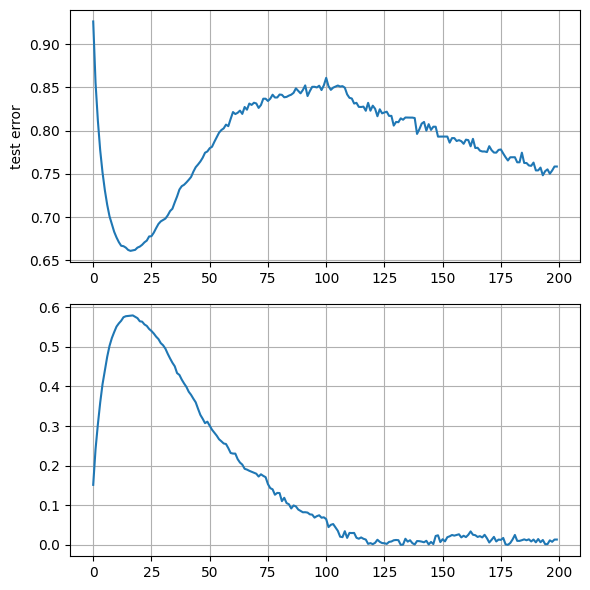

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), tight_layout=True)

ax1.plot(test_errs)
ax1.set_ylabel('test error')
ax1.grid()

ax2.plot(np.abs(e12/e01-1))
ax2.grid()

plt.show()

In [28]:
# np.savetxt('dev_unfo.csv', e12/e01-1, delimiter=',')